### Cell 1 — Imports & Global Settings

Purpose

Minimal imports

No econometrics packages needed

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [ ]:
df_path = "../data/results/no_desc/no_desc_scored.csv"

out_path = "../data/results/no_desc/"

### Cell 2 — Load & Basic Preparation

Purpose

Load scored dataset

Ensure consistent ordering

Do not estimate anything yet

In [3]:
df = pd.read_csv(df_path, encoding="ISO-8859-1", index_col=0)

df = df.sort_values(["essay_id", "k"]).reset_index(drop=True)

df.head()

,essay_id,k,true_score,low_SES,race_white,gender_male,prompt_name,grade_level,cv_fold,score_high_full,...,score_high_style,score_low_style,score_high_emb,score_low_emb,score_high_taaled,score_low_taaled,score_high_taaco,score_low_taaco,score_high_taassc,score_low_taassc
0,00009d59-fa66-4a21-ab82-c9585bafbb0f,0,4,True,False,True,Driverless cars,10.0,4,3.637174,...,3.438643,3.481185,3.860600,4.249443,2.930261,3.573276,3.039818,3.535388,3.377237,3.367541
1,00009d59-fa66-4a21-ab82-c9585bafbb0f,1,4,True,False,True,Driverless cars,10.0,4,4.192033,...,3.709846,3.815495,4.152442,3.215453,3.229372,2.222043,2.921947,2.866734,3.985426,3.691179
2,00009d59-fa66-4a21-ab82-c9585bafbb0f,2,4,True,False,True,Driverless cars,10.0,4,3.670534,...,3.581281,3.521638,3.482001,3.221166,3.195001,2.265397,3.239982,2.792430,3.873919,3.938105
3,00009d59-fa66-4a21-ab82-c9585bafbb0f,3,4,True,False,True,Driverless cars,10.0,4,3.423853,...,3.420937,3.526902,3.480083,3.427265,2.889353,2.001542,2.644537,2.798266,3.508848,3.761918
4,00009d59-fa66-4a21-ab82-c9585bafbb0f,4,4,True,False,True,Driverless cars,10.0,4,4.177666,...,4.084588,3.633393,3.970586,3.334008,3.312156,2.224336,3.098073,3.018300,4.130281,3.829347


### Cell 3 — Define Key Masks / Conventions

Purpose
Make assumptions explicit, matching the paper’s notation.

This is critical for transparency.

In [4]:
# SES groups
mask_H = df["low_SES"] == 0   # High SES
mask_L = df["low_SES"] == 1   # Low SES

# Rewrite status
mask_orig = df["k"] == 0      # Original text
mask_neu  = df["k"] == 1      # Neutral (GPT-style) rewrite

### Cell 4 — Utility: Safe Conditional Mean

Purpose
Reusable helper, mirrors your FE notebook style.

In [6]:
def mean_mask(s: pd.Series, mask: pd.Series) -> float:
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan

### Cell 5 — Compute Group Means (Core Objects)

Purpose
These are the μ terms in the paper.
Everything else is algebra.

In [7]:
# --- Under scorer S(H)
mu_H_orig = mean_mask(df["score_high_full"], mask_H & mask_orig)
mu_L_orig = mean_mask(df["score_high_full"], mask_L & mask_orig)

mu_H_neu  = mean_mask(df["score_high_full"], mask_H & mask_neu)
mu_L_neu  = mean_mask(df["score_high_full"], mask_L & mask_neu)

# --- Under scorer S(L), originals only
mu_L_orig_Lscorer = mean_mask(df["score_low_full"], mask_L & mask_orig)

means = {
    "mu_H_orig": mu_H_orig,
    "mu_L_orig": mu_L_orig,
    "mu_H_neu": mu_H_neu,
    "mu_L_neu": mu_L_neu,
    "mu_L_orig_Lscorer": mu_L_orig_Lscorer
}

means


{'mu_H_orig': 3.639631589364649,
 'mu_L_orig': 3.0169349488464996,
 'mu_H_neu': 3.890952572895983,
 'mu_L_neu': 3.392093283603853,
 'mu_L_orig_Lscorer': 2.9824064820014757}

### Cell 6 — Baseline (Neutral) Decomposition

In [8]:
total_gap = mu_H_orig - mu_L_orig

content_gap = mu_H_neu - mu_L_neu

style_gap = (
    (mu_H_orig - mu_H_neu)
    -
    (mu_L_orig - mu_L_neu)
)

scorer_gap = mu_L_orig - mu_L_orig_Lscorer

decomp = {
    "total_gap": total_gap,
    "content_gap": content_gap,
    "style_gap": style_gap,
    "scorer_gap": scorer_gap,
    "share_content": content_gap / total_gap if total_gap else np.nan,
    "share_style": style_gap / total_gap if total_gap else np.nan,
    "share_scorer": scorer_gap / total_gap if total_gap else np.nan,
}

decomp


{'total_gap': 0.6226966405181495,
 'content_gap': 0.4988592892921302,
 'style_gap': 0.12383735122601935,
 'scorer_gap': 0.034528466845023864,
 'share_content': 0.8011273175924418,
 'share_style': 0.19887268240755815,
 'share_scorer': 0.05544990063908571}

### Saving Results in DataFrame

In [11]:
def build_neutral_decomp_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # --- Identify original and neutral rows
    df_orig = df[df["k"] == 0].copy()
    df_neu  = df[df["k"] == 1].copy()

    # --- Drop grade levels 9.0 and 12.0
    df_orig = df_orig[~df_orig["grade_level"].isin([9.0, 12.0])]
    df_neu  = df_neu[df_neu["essay_id"].isin(df_orig["essay_id"])]

    # --- Keep only columns needed for merging
    keep_cols = [
        "essay_id", "low_SES", "race_white", "gender_male",
        "prompt_name", "grade_level", "cv_fold",
        "score_high_full", "score_low_full"
    ]

    df_orig = df_orig[keep_cols].rename(columns={
        "score_high_full": "score_high_orig",
        "score_low_full":  "score_low_orig"
    })

    df_neu = df_neu[[
        "essay_id", "score_high_full"
    ]].rename(columns={
        "score_high_full": "score_high_neu"
    })

    # --- Merge original + neutral
    out = df_orig.merge(df_neu, on="essay_id", how="inner")

    # --- Row-level neutral decomposition
    out["content_neu"] = out["score_high_neu"]
    out["style_premium"] = out["score_high_orig"] - out["score_high_neu"]

    # --- Scorer difference (original)
    out["diff_high_low_orig"] = (
        out["score_high_orig"] - out["score_low_orig"]
    )

    # --- Restore k column meaningfully
    out["k"] = 0

    return out

In [15]:
df_neutral_decomp = build_neutral_decomp_df(df)

df_neutral_decomp.to_csv(
    out_path + "decomp_rows_neutral.csv",
    index=False
)

df_neutral_decomp.head()


,essay_id,low_SES,race_white,gender_male,prompt_name,grade_level,cv_fold,score_high_orig,score_low_orig,score_high_neu,content_neu,style_premium,diff_high_low_orig,k
0,00009d59-fa66-4a21-ab82-c9585bafbb0f,True,False,True,Driverless cars,10.0,4,3.637174,3.610687,4.192033,4.192033,-0.554859,0.026486,0
1,0003b509-e82c-4905-b76b-b4145f453b36,False,True,False,Cell phones at school,8.0,2,2.582573,2.607545,2.758356,2.758356,-0.175784,-0.024973,0
2,00088121-1a97-4d80-ba45-44c51d828ff2,True,False,True,Community service,8.0,5,3.078734,2.636030,3.080454,3.080454,-0.001720,0.442703,0
3,00092bf2-6089-44b7-9429-d03ae74aa24a,False,True,False,Grades for extracurricular activities,8.0,5,2.896804,2.922007,3.153955,3.153955,-0.257151,-0.025203,0
4,000a79a3-0028-4c9b-8358-45465fd690e4,False,False,False,Community service,8.0,4,4.755594,4.770242,5.044900,5.044900,-0.289306,-0.014648,0


### Images generation

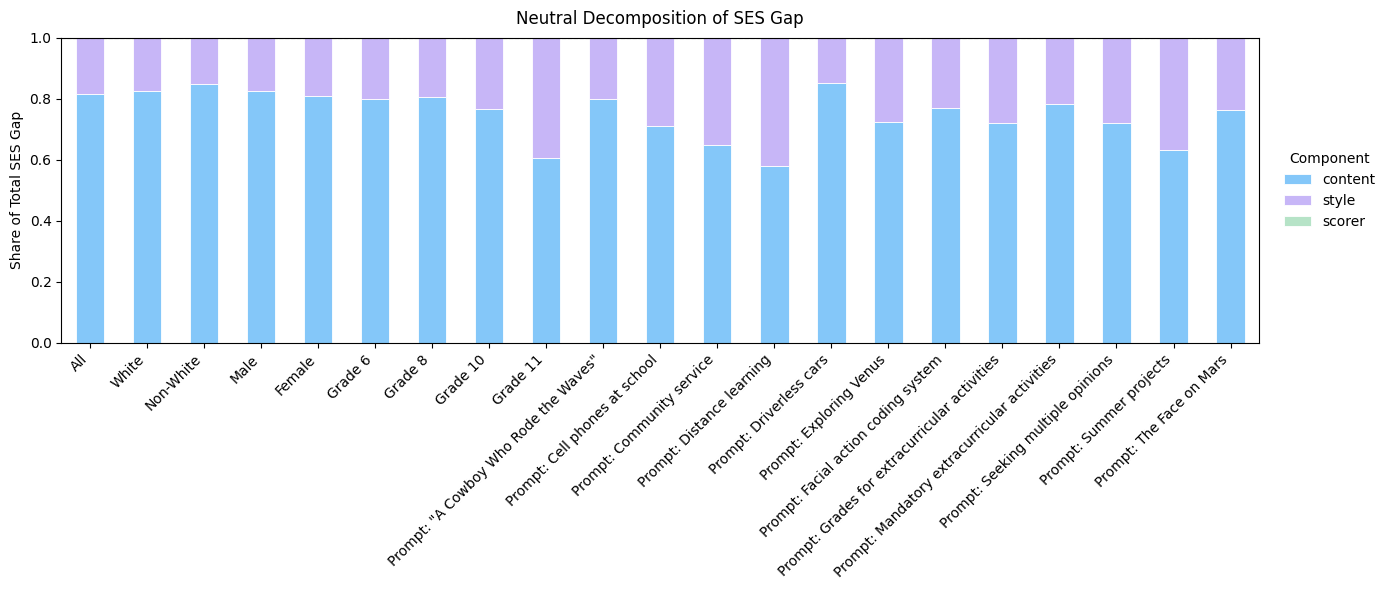

In [ ]:
# ==============================
# Neutral Decomposition – Plot Test Cell
# ==============================

# ---------- Component config (NEUTRAL) ----------
COMP_ORDER = ["content", "style", "scorer"]
COMP_COLORS = {
    "content": "#84C7F9",   # blue
    "style":   "#C7B6F7",   # purple
    "scorer":  "#B6E3C7"    # green
}

# ---------- Utilities ----------
def _mean_mask(s, mask):
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan


# ---------- Core: neutral decomposition shares ----------
def _compute_decomp(df_sub):
    # Decomposition defined on original rows only
    df0 = df_sub[df_sub["k"] == 0].copy()

    mH = df0["low_SES"] == 0
    mL = df0["low_SES"] == 1

    if not (mH.any() and mL.any()):
        return pd.Series({c: np.nan for c in COMP_ORDER})

    # --- total gap (under high scorer)
    mean_H = _mean_mask(df0["score_high_orig"], mH)
    mean_L = _mean_mask(df0["score_high_orig"], mL)
    total_gap = mean_H - mean_L

    if not total_gap:
        return pd.Series({c: np.nan for c in COMP_ORDER})

    # --- content (neutral baseline)
    content_H = _mean_mask(df0["content_neu"], mH)
    content_L = _mean_mask(df0["content_neu"], mL)
    content_gap = content_H - content_L

    # --- style (premium)
    style_H = _mean_mask(df0["style_premium"], mH)
    style_L = _mean_mask(df0["style_premium"], mL)
    style_gap = style_H - style_L

    # --- scorer tilt (low SES only)
    scorer_gap = _mean_mask(df0["diff_high_low_orig"], mL)

    return pd.Series({
        "content": content_gap / total_gap,
        "style":   style_gap   / total_gap,
        "scorer":  scorer_gap  / total_gap
    })


# ---------- Grouped decomposition ----------
def compute_decomp_shares(df_decomp):
    df = df_decomp.copy()
    groups = {"All": df}

    # by race / gender
    for g in ["race_white", "gender_male"]:
        if g in df.columns:
            groups[f"{g}=True"]  = df[df[g] == True]
            groups[f"{g}=False"] = df[df[g] == False]

    # by grade level
    if "grade_level" in df.columns:
        for gl in sorted(df["grade_level"].dropna().unique()):
            groups[f"grade_level={gl}"] = df[df["grade_level"] == gl]

    # by prompt
    if "prompt_name" in df.columns:
        for p in sorted(df["prompt_name"].dropna().unique()):
            groups[f"Prompt: {p}"] = df[df["prompt_name"] == p]

    out = pd.DataFrame({k: _compute_decomp(v) for k, v in groups.items()}).T
    return out.reindex(columns=COMP_ORDER)


# ---------- Plot ----------
def plot_stacked(df_shares, figsize=(14,6), xtick_rotation=45, title=None):
    if df_shares.empty:
        print("Nothing to plot.")
        return

    ax = df_shares[COMP_ORDER].plot(
        kind="bar",
        stacked=True,
        color=[COMP_COLORS[c] for c in COMP_ORDER],
        edgecolor="white",
        linewidth=0.6,
        figsize=figsize
    )

    ax.set_ylabel("Share of Total SES Gap")
    ax.set_ylim(0, 1)
    ax.axhline(1, color="gray", lw=0.8, linestyle="--")
    ax.set_xlabel("")
    if title:
        ax.set_title(title, pad=10)

    plt.xticks(rotation=xtick_rotation, ha="right")
    ax.legend(
        title="Component",
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )
    plt.tight_layout()
    plt.show()


# ---------- Label map ----------
GROUP_LABELS = {
    "All": "All",
    "race_white=True": "White",
    "race_white=False": "Non-White",
    "gender_male=True": "Male",
    "gender_male=False": "Female",
    "grade_level=6.0": "Grade 6",
    "grade_level=8.0": "Grade 8",
    "grade_level=10.0": "Grade 10",
    "grade_level=11.0": "Grade 11",
}

# ---------- RUN ----------
decomp_shares = compute_decomp_shares(df_neutral_decomp)

# nicer labels
decomp_shares_plot = decomp_shares.copy()
decomp_shares_plot.index = decomp_shares_plot.index.map(
    lambda x: GROUP_LABELS.get(x, x)
)

plot_stacked(
    decomp_shares_plot,
    title="Neutral Decomposition of SES Gap"
)

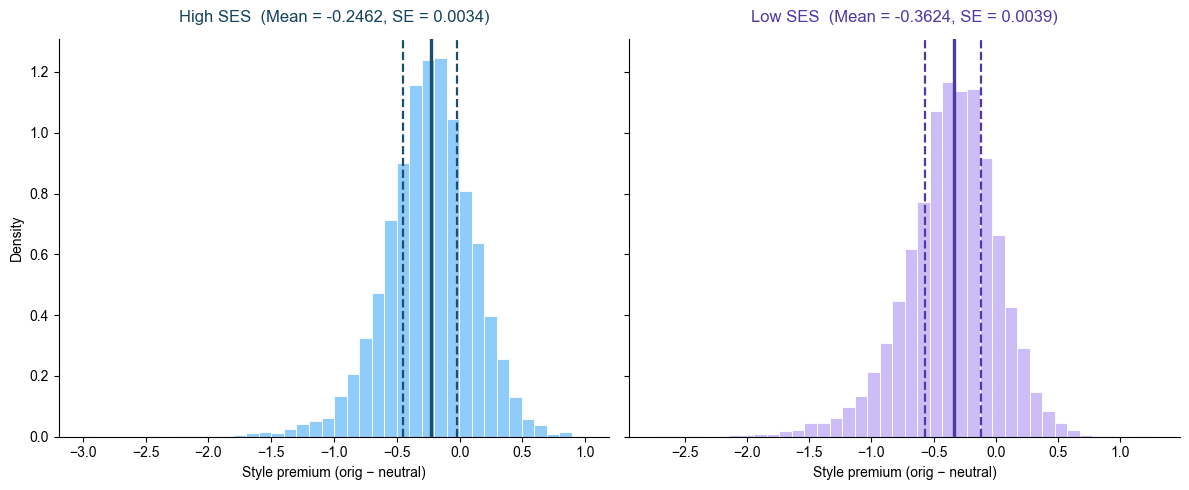

In [ ]:
# ==============================
# Neutral Decomposition: Style Distribution by SES
# ==============================

# --- Data (original essays only; neutral decomp DF) ---
mask = (df_neutral_decomp["k"] == 0) & df_neutral_decomp["style_premium"].notna()
df_s = df_neutral_decomp.loc[mask, ["low_SES", "style_premium"]].astype(float)

# Split by SES
s_high = df_s[df_s["low_SES"] == 0]["style_premium"]
s_low  = df_s[df_s["low_SES"] == 1]["style_premium"]

# --- Helper for summary stats ---
def describe(x):
    return {
        "mean": x.mean(),
        "se": x.std(ddof=1) / np.sqrt(len(x)),
        "q1": np.percentile(x, 25),
        "med": np.percentile(x, 50),
        "q3": np.percentile(x, 75),
    }

stats_high = describe(s_high)
stats_low  = describe(s_low)

# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.set_style("whitegrid")

# ---------- HIGH SES ----------
sns.histplot(
    s_high, bins=40, stat="density",
    color="#84C7F9", edgecolor="white",
    linewidth=0.6, alpha=0.9, ax=axes[0]
)
for val, ls, lw in zip(
    [stats_high["q1"], stats_high["med"], stats_high["q3"]],
    ["--", "-", "--"],
    [1.6, 2.4, 1.6],
):
    axes[0].axvline(val, color="#1B4F72", linestyle=ls, linewidth=lw, zorder=3)

axes[0].set_title(
    f"High SES  (Mean = {stats_high['mean']:.4f}, SE = {stats_high['se']:.4f})",
    fontsize=12, color="#154360", pad=12
)
axes[0].set_xlabel("Style premium (orig − neutral)")
axes[0].set_ylabel("Density")

# ---------- LOW SES ----------
sns.histplot(
    s_low, bins=40, stat="density",
    color="#C7B6F7", edgecolor="white",
    linewidth=0.6, alpha=0.9, ax=axes[1]
)
for val, ls, lw in zip(
    [stats_low["q1"], stats_low["med"], stats_low["q3"]],
    ["--", "-", "--"],
    [1.6, 2.4, 1.6],
):
    axes[1].axvline(val, color="#4E3AA3", linestyle=ls, linewidth=lw, zorder=3)

axes[1].set_title(
    f"Low SES  (Mean = {stats_low['mean']:.4f}, SE = {stats_low['se']:.4f})",
    fontsize=12, color="#4E3AA3", pad=12
)
axes[1].set_xlabel("Style premium (orig − neutral)")
axes[1].set_ylabel("")

# --- Style ---
for ax in axes:
    sns.despine(ax=ax)
    ax.axhline(0, color="gray", lw=0.5)

plt.tight_layout()
# plt.savefig(
#     f"{SAVE_DIR}neutral_style_distribution_by_SES_dual.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()


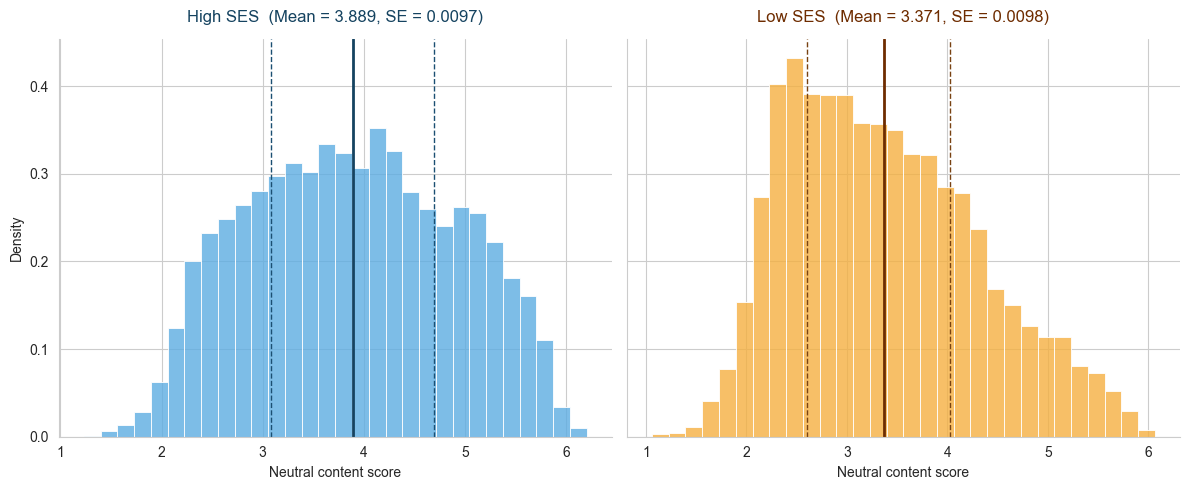

In [ ]:
# ==============================
# Neutral Decomposition: Content Distribution by SES
# ==============================

# --- Data (original essays only; neutral DF) ---
mask = (df_neutral_decomp["k"] == 0) & df_neutral_decomp["content_neu"].notna()
df_plot = df_neutral_decomp.loc[mask, ["low_SES", "content_neu"]].astype(float)

# Split by SES
low_df  = df_plot[df_plot["low_SES"] == 1]["content_neu"]
high_df = df_plot[df_plot["low_SES"] == 0]["content_neu"]

# --- Helper to compute stats ---
def describe(x):
    return {
        "mean": x.mean(),
        "se": x.std(ddof=1) / np.sqrt(len(x)),
        "q1": np.percentile(x, 25),
        "q3": np.percentile(x, 75),
    }

stats_low  = describe(low_df)
stats_high = describe(high_df)

# --- Create side-by-side figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.set_style("whitegrid")

# ---------- HIGH SES ----------
sns.histplot(
    high_df, bins=30, stat="density",
    color="#5DADE2", edgecolor="white",
    linewidth=0.6, alpha=0.8, ax=axes[0]
)
axes[0].axvline(stats_high["q1"], color="#1B4F72", linestyle="--", linewidth=1)
axes[0].axvline(stats_high["q3"], color="#1B4F72", linestyle="--", linewidth=1)
axes[0].axvline(stats_high["mean"], color="#154360", linewidth=2)

axes[0].set_title(
    f"High SES  (Mean = {stats_high['mean']:.3f}, SE = {stats_high['se']:.4f})",
    fontsize=12, color="#154360", pad=12
)
axes[0].set_xlabel("Neutral content score")
axes[0].set_ylabel("Density")

# ---------- LOW SES ----------
sns.histplot(
    low_df, bins=30, stat="density",
    color="#F5B041", edgecolor="white",
    linewidth=0.6, alpha=0.8, ax=axes[1]
)
axes[1].axvline(stats_low["q1"], color="#784212", linestyle="--", linewidth=1)
axes[1].axvline(stats_low["q3"], color="#784212", linestyle="--", linewidth=1)
axes[1].axvline(stats_low["mean"], color="#6E2C00", linewidth=2)

axes[1].set_title(
    f"Low SES  (Mean = {stats_low['mean']:.3f}, SE = {stats_low['se']:.4f})",
    fontsize=12, color="#6E2C00", pad=12
)
axes[1].set_xlabel("Neutral content score")
axes[1].set_ylabel("")

# --- Styling ---
for ax in axes:
    sns.despine(ax=ax)
    ax.axhline(0, color="gray", lw=0.5)

plt.tight_layout()
# plt.savefig(
#     f"{SAVE_DIR}neutral_content_distribution_by_SES_dual.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()
